In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass

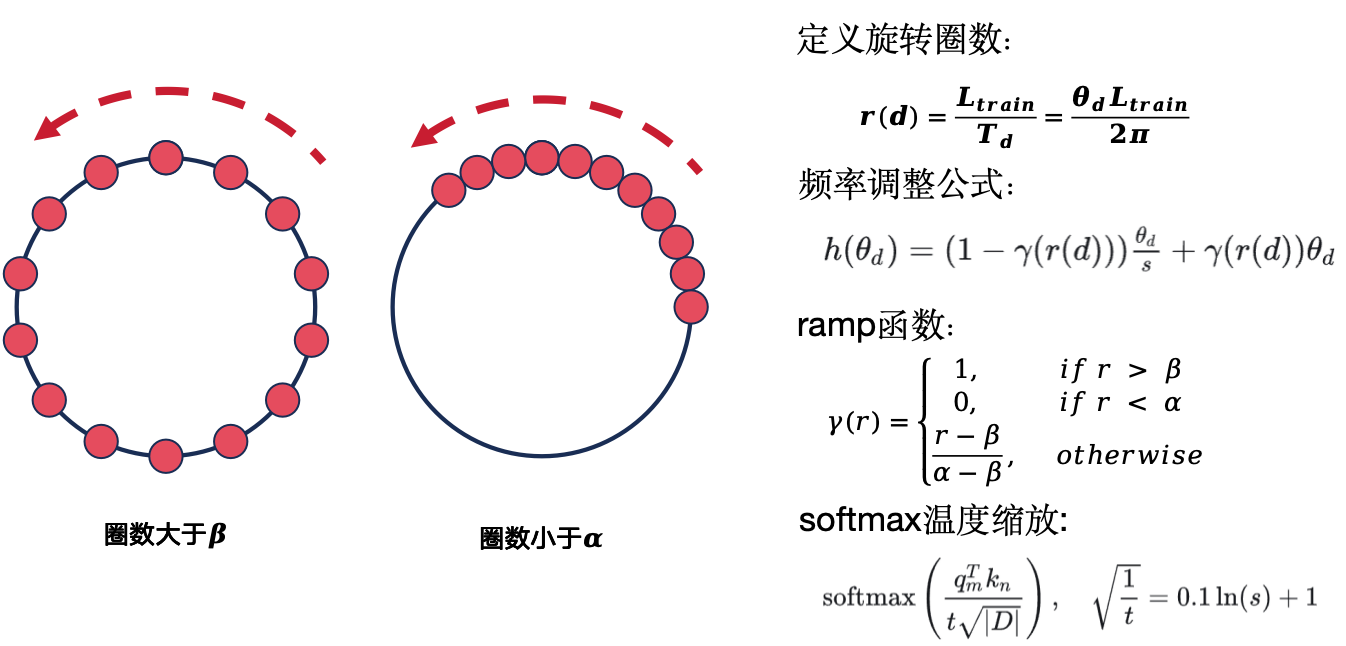

In [2]:
from IPython.display import Image, display
image_path = r'C:/Users/1/Desktop/YaRN.png'  # ← 修改这里！
display(Image(filename=image_path))

# 手写YaRN位置编码

In [3]:
@dataclass
class Config:
    n_head: int
    head_dim: int
    origin_seq: int
    max_seq: int
    low: int
    high: int
    base: int
    factor: float

In [5]:
def get_index(r, dim, base, max_seq):
    # 根据比值（圈数）来获取dim的index
    # get_index 把这些圈数阈值，翻译成对应的维度索引
    return dim * math.log(max_seq / (r * 2 * math.pi)) / (2 * math.log(base))

def get_low_and_high_dim(low, high, dim, base, max_seq):

    # low < high
    low = math.floor(get_index(low, dim, base, max_seq)) # 高频的index
    high = math.ceil(get_index(high, dim, base, max_seq)) # 低频的index

    # 确保low不能小于0， high不能大于dim-1
    return max(low, 0), min(high, dim-1)

def ramp_func(low, high, dim):
    # 这里就根据ramp公式计算 (r - low) / (high - low)
    #ramp_func 拿到这些索引边界后，就不再关心圈数了。它只关心：“对于第 i 个维度，它距离高频边界有多远？
    linear_func = (torch.arange(dim, dtype=torch.float32) - low) / (high - low)

    # 同样，这里要确保ramp函数结果再[0, 1]
    return torch.clamp(linear_func, 0, 1)


def precompute_freqs_cis(args):
    # 先得到一个基本的频率范围, [0, D/2]
    freqs_range = torch.arange(0, args.head_dim, 2, dtype=torch.float32) # [0, 2, 4, ..., D-1], 元素个数是 D//2
    # base^(-2i/d)
    freqs = 1.0 / (args.base ** (freqs_range / args.head_dim))

    # 如果要做长度外推
    if args.max_seq > args.origin_seq:
        # 这里要注意，low应该获取的是高频的index，high是低频的
        low, high = get_low_and_high_dim(args.high, args.low, args.head_dim, args.base, args.max_seq)

        # 插值函数：如果是大于high，smooth应该等于0，都则如果小于low，smooth应该等于1.
        smooth = 1 - ramp_func(low, high, args.head_dim // 2)

        # 根据不同的情况做插值策略，smooth=1，就不插值，smooth=0，就完全插值
        freqs = (1 - smooth) * freqs / args.factor + smooth * freqs # [head_dim//2, ]

    # 做一个笛卡尔积，对每一个位置都做一次
    max_seq_arange = torch.arange(args.max_seq)
    freqs = torch.outer(max_seq_arange, freqs)

    # 得到复数域的频率, 第一个参数是模长（都为1， 也就是都在单位圆上旋转，第二个参数是相位角度， 也就是theta）
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs) # [max_seq, head_dim//2]

    return freqs_cis


def apply_rotary_emb(x, freqs_cis):
    batch, max_seq, n_head, head_dim = x.shape

    # 把x的dim那个维度分成2部分
    x = torch.view_as_complex(x.view(batch, max_seq, n_head, -1, 2))

    # 计算所有位置 + 所有维度的频率矩阵
    freqs_cis = freqs_cis.view(1, max_seq, 1, x.size(-1)) # 对每一个样本和每一个头的旋转变换都是一样的

    # 对输入x施加旋转变换
    rotate_x = torch.view_as_real(x * freqs_cis).flatten(3)

    return rotate_x

In [6]:

config = Config(
    n_head = 8,
    head_dim = 128,
    origin_seq = 8096, # 原始的序列长度，8k
    max_seq = 8096 * 4, # 要外推的序列长度， 32k
    low = 1, # 最小的圈数阈值
    high = 32, # 最大的圈数阈值
    base = 10000.0, # 基频base
    factor = 10 # 插值的因子，也就是那个s
)

query = torch.randn(1, config.max_seq, config.n_head, config.head_dim)
print("Original query shape: ", query.shape)

freqs_cis = precompute_freqs_cis(config)
print("Frequency shape: ", freqs_cis.shape)

query_rotate = apply_rotary_emb(query, freqs_cis)
print("Rotated query shape: ", query_rotate.shape)

Original query shape:  torch.Size([1, 32384, 8, 128])
Frequency shape:  torch.Size([32384, 64])
Rotated query shape:  torch.Size([1, 32384, 8, 128])


D:\Anaconda\envs\pytorch\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
D:\Anaconda\envs\pytorch\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


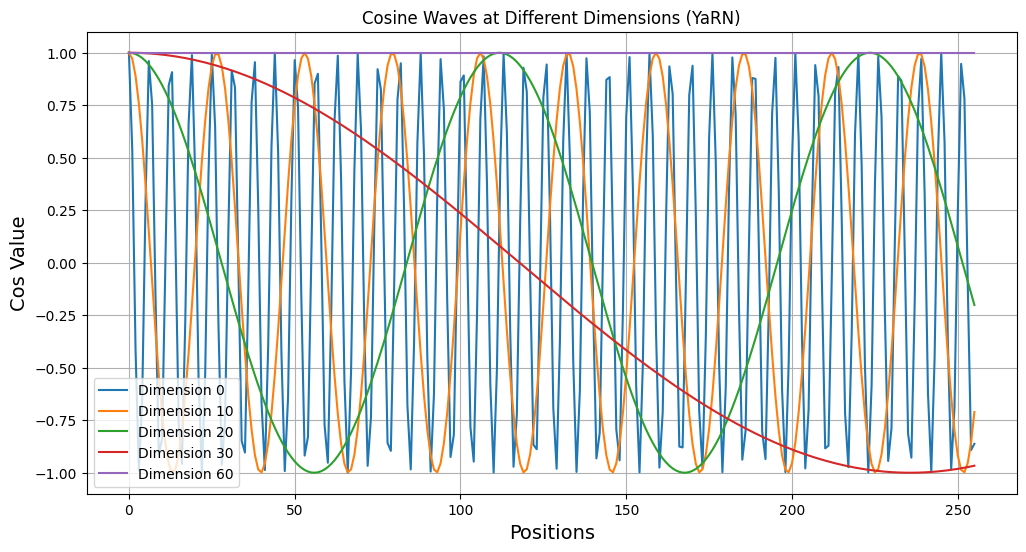

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

# 选择5个不同的维度的周期剥削来绘制
channels_to_plot = [0, 10, 20, 30, 60]

for i in channels_to_plot:
    plt.plot(freqs_cis[:256, i], label=f'Dimension {i}')

plt.title("Cosine Waves at Different Dimensions (YaRN)")
plt.xlabel("Positions", fontsize=14)
plt.ylabel("Cos Value", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()